<a href="https://colab.research.google.com/github/Arshi-yaaaa/Real-world-Data-Project/blob/main/Real_world_data_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive (4).zip


In [24]:
import zipfile

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

In [25]:
import os
os.listdir('data')

['titanic.csv', 'n_movies.csv']

In [26]:
import pandas as pd

df = pd.read_csv('data/n_movies.csv')
df.head()

,title,year,certificate,duration,genre,rating,description,stars,votes
0,Cobra Kai,(2018– ),TV-14,30 min,"Action, Comedy, Drama",8.5,Decades after their 1984 All Valley Karate Tou...,"['Ralph Macchio, ', 'William Zabka, ', 'Courtn...","177,031"
1,The Crown,(2016– ),TV-MA,58 min,"Biography, Drama, History",8.7,Follows the political rivalries and romance of...,"['Claire Foy, ', 'Olivia Colman, ', 'Imelda St...","199,885"
2,Better Call Saul,(2015–2022),TV-MA,46 min,"Crime, Drama",8.9,The trials and tribulations of criminal lawyer...,"['Bob Odenkirk, ', 'Rhea Seehorn, ', 'Jonathan...","501,384"
3,Devil in Ohio,(2022),TV-MA,356 min,"Drama, Horror, Mystery",5.9,When a psychiatrist shelters a mysterious cult...,"['Emily Deschanel, ', 'Sam Jaeger, ', 'Gerardo...","9,773"
4,Cyberpunk: Edgerunners,(2022– ),TV-MA,24 min,"Animation, Action, Adventure",8.6,A Street Kid trying to survive in a technology...,"['Zach Aguilar, ', 'Kenichiro Ohashi, ', 'Emi ...","15,413"


In [27]:
print(df.shape)
df.info()
df.describe()

(9957, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9957 entries, 0 to 9956
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   title        9957 non-null   object 
 1   year         9430 non-null   object 
 2   certificate  6504 non-null   object 
 3   duration     7921 non-null   object 
 4   genre        9884 non-null   object 
 5   rating       8784 non-null   float64
 6   description  9957 non-null   object 
 7   stars        9957 non-null   object 
 8   votes        8784 non-null   object 
dtypes: float64(1), object(8)
memory usage: 700.2+ KB


,rating
count,8784.000000
mean,6.764515
std,1.214840
min,1.700000
25%,6.100000
50%,6.900000
75%,7.600000
max,9.900000


In [28]:
df.isnull().sum()

,0
title,0
year,527
certificate,3453
duration,2036
genre,73
rating,1173
description,0
stars,0
votes,1173


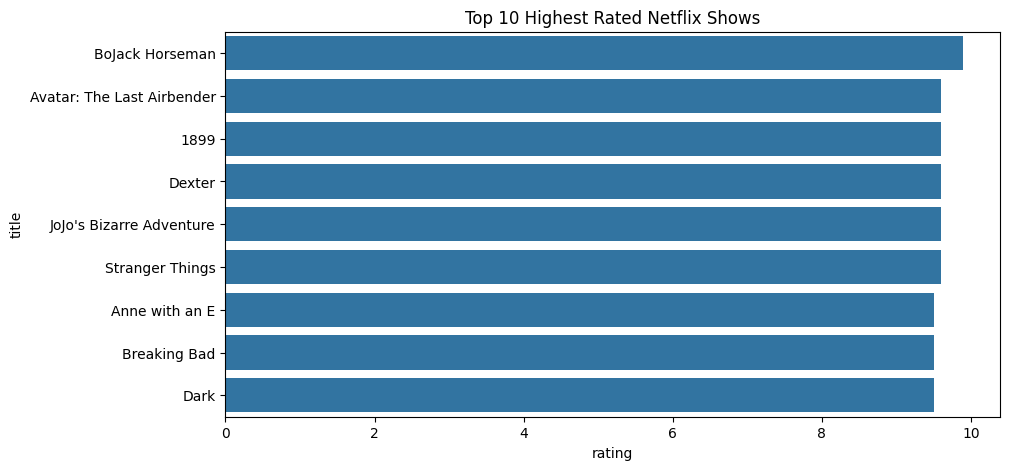

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

top_rated = df.sort_values(by='rating', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x='rating', y='title', data=top_rated)
plt.title('Top 10 Highest Rated Netflix Shows')
plt.show()

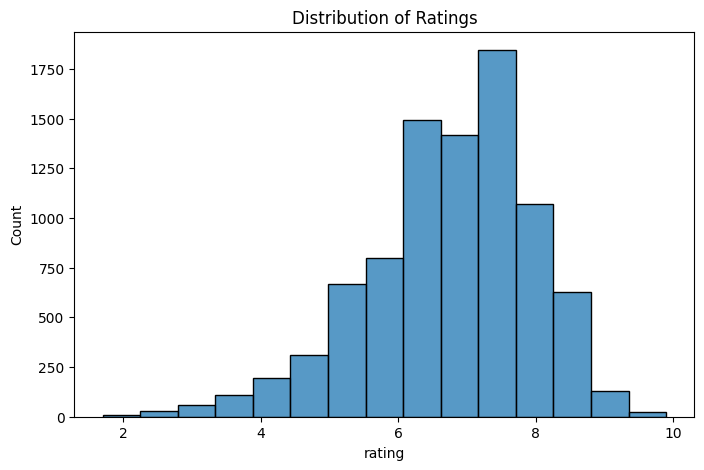

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df['rating'], bins=15)
plt.title('Distribution of Ratings')
plt.show()

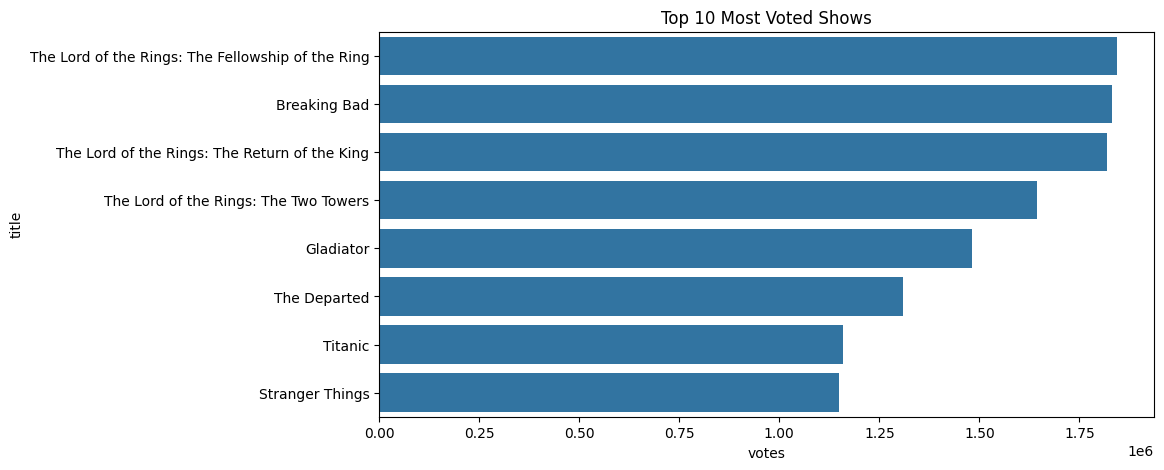

In [31]:
df['votes'] = df['votes'].astype(str).str.replace(',', '', regex=False)

df['votes'] = pd.to_numeric(df['votes'], errors='coerce')

df['votes'] = df['votes'].fillna(0)

top_votes = df.sort_values(by='votes', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x='votes', y='title', data=top_votes)
plt.title('Top 10 Most Voted Shows')
plt.show()

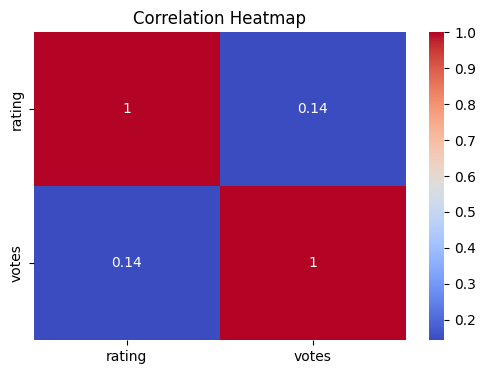

In [32]:
numeric_df = df[['rating', 'votes']]

plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

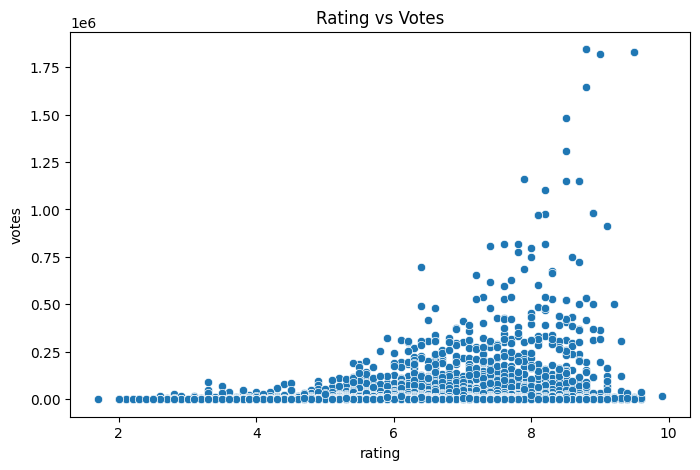

In [33]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='rating', y='votes', data=df)
plt.title('Rating vs Votes')
plt.show()